# ENGR 1451/2451 — Weekly Assignment 3
**10 points**

This assignment applies programming, normal-approximation, and central-limit-theorem ideas.


**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

No external data file is needed for this assignment.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm


## LE3-1. Detecting abrupt changes in a sequence (2 pts)

Thickness is measured at consecutive positions along a coated sample. A change of **5 nm or more in magnitude** between neighboring positions is considered abrupt.

### A. Loop solution (1 pt)

Using `range`, an `if` statement, and `.append()`, calculate each change from one position to the next and store it in `changes_loop`. Store the position pairs with abrupt changes in `abrupt_pairs_loop`. **Report position numbers starting at 1**; for example, `(1, 2)` means the change from the first measurement to the second measurement.


In [2]:
thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]
settings = {"abrupt_change_nm": 5}

changes_loop = []
abrupt_pairs_loop = []

# Your code here
observation_count = len(thickness_nm)
for i in range(observation_count-1):
    changes_loop.append(thickness_nm[i+1] - thickness_nm[i])

    if(abs(changes_loop[i]) >= settings["abrupt_change_nm"]): #flagging abrubt changes, absolute value covers negative differences
        abrupt_pairs_loop.append((i+1,i+2))

#Checking work
print(changes_loop)
print(abrupt_pairs_loop)

[2, -1, 6, 1, -3, 6, -1]
[(3, 4), (6, 7)]


### B. Vectorized solution (1 pt)

Convert the data to a NumPy array and use `np.diff()` to calculate the same changes without an explicit loop. Use a Boolean mask to identify abrupt changes. Verify agreement with the loop solution and report the affected position pairs.

**Answer:**


In [13]:
# Your vectorized code and comparison here
thickness_nm_array = np.array(thickness_nm)

changes_vectorized = np.diff(thickness_nm_array)
abrupt_pairs_vectorized_mask = np.abs(changes_vectorized) >= 5
abrupt_pairs_vectorized = np.arange(1,observation_count)[abrupt_pairs_vectorized_mask] #creating an array from 1 to 8 and selecting affected numbers using mask
abrupt_pairs_vectorized = list(zip(abrupt_pairs_vectorized.tolist(),(abrupt_pairs_vectorized+1).tolist())) #creating list of tuples from abprupt pair postions

#Checking work
print(changes_vectorized)
print(abrupt_pairs_vectorized)

#Verifiying agreement
equality_condition_changes = np.array_equal(changes_loop,changes_vectorized)
equality_condition_pairs = abrupt_pairs_vectorized == abrupt_pairs_loop
print("Consecutive measurement changes parity between loop and vectorization:",equality_condition_changes)
print("Abrupt changes list parity between loop and vectorization:",equality_condition_pairs)
print("Affected pairs:",abrupt_pairs_vectorized)

[ 2 -1  6  1 -3  6 -1]
[(3, 4), (6, 7)]
Consecutive measurement changes parity between loop and vectorization: True
Abrupt changes list parity between loop and vectorization: True
Affected pairs: [(3, 4), (6, 7)]


## LE3-2. Raw scores and a normal approximation (2 pts)

For Part B, use a normal model with **mean = 50** and **SD = 10**. **Do not estimate these values from the raw scores.**

### A. Density histogram from raw data (1 pt)

Make a **density histogram** using the supplied equal-width bins. Then use `np.histogram(..., density=True)` to calculate the density heights and verify

\[
\sum_i (\text{density}_i)(\text{bin width}_i)=1.
\]

Also calculate the sum of the density heights. Why do the heights themselves not need to sum to 1?


sum(bin heights * bin widths) == 1 is: True
sum(density heights) =  0.2325581395348838
[4.3 4.3 4.3 4.3 4.3 4.3 4.3 4.3 4.3 4.3]


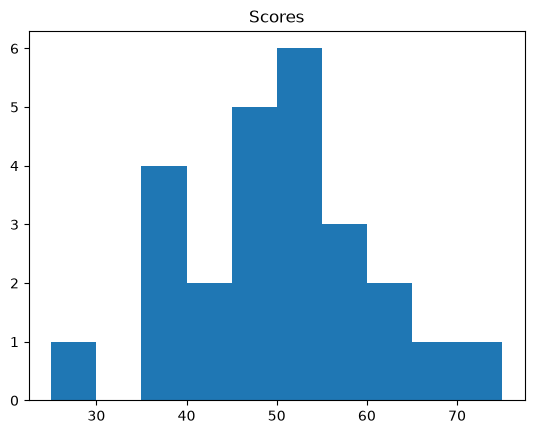

In [ ]:
scores = np.array([
    39, 41, 47, 58, 65, 37, 37, 49, 56, 59, 62, 36, 48,
    52, 64, 29, 44, 47, 49, 52, 53, 54, 72, 50, 50
])

bins = np.arange(25, 76, 5)

# Create the density histogram and verify its total area.
# Your code here
#Creating histogram
plt.hist(scores,bins = bins)
plt.title("Scores")

#Density height calculations
counts, bin_edges = np.histogram(scores, density=True)
bin_widths = np.diff(bin_edges) #using the bin edges to find the bin widths
equality_verification = sum(counts * bin_widths) == 1
print("sum(bin heights * bin widths) == 1 is:",equality_verification)
print("sum(density heights) = ",sum(counts))

**Answer:**
The desnity heights do not sum up to 1 because of the fact that the bins do not have bin widths of 1. The total area of the density histogram is equal to 1, which means that having bin widths equal to 1 is the only way to get the sum of the heights to equal to 1.


### B. Approximation versus actual data (1 pt)

Using the supplied normal model with **mean = 50** and **SD = 10**, estimate the percentage and number of the 25 scores within **1.25 SDs** of the mean. Then count how many raw scores actually fall in that interval. Round the fitted count to the nearest whole student and compare.


In [54]:
# Your normal approximation and observed count here
mean_score = 50
score_std = 10
upper_score = mean_score+1.25*score_std
lower_score = mean_score-1.25*score_std
percentage_in_interval = norm.cdf(upper_score,loc = mean_score,scale = score_std) - norm.cdf(lower_score, loc = mean_score, scale = score_std)
scores_mask = (scores <= upper_score) & (scores >= lower_score)
number_in_interval = scores_mask.sum() #taking the sum of values that satisfy the mask
print("Percentage of scores between +- 1.25 SDs of mean:",round(percentage_in_interval,4),
      "\n\tFitted count in the interval:",round(25*percentage_in_interval),
      "\n\tNumber of scores actually in the interval:",number_in_interval)

Percentage of scores between +- 1.25 SDs of mean: 0.7887 
	Fitted count in the interval: 20 
	Number of scores actually in the interval: 18


**Answer:** The fitted count, 20, included 2 more students than the actual number of students in the interval, 18.



## LE3-3. Normal model for engineering specifications (4 pts)

Shaft diameters are modeled by a normal curve with \(\mu=10.00\) mm and \(\sigma=0.12\) mm. The acceptable range is **9.80–10.20 mm**. Assume the normal model is appropriate.

### A. Fraction meeting specification (1.5 pts)

Calculate the fitted percentages **below**, **within**, and **above** specification, and check that they total about 100%. Why are the two tail percentages equal?


In [61]:
mean_diameter = 10.00
std_diameter = 0.12
lower_spec = 9.80
upper_spec = 10.20

# Create the normal model and calculate the probabilities here
model = norm(loc = mean_diameter, scale = std_diameter)
below_spec = model.cdf(lower_spec) #cdf = lef tail
above_spec = model.sf(upper_spec) #sf = right tail
within_spec = 1 - (below_spec + above_spec) #finding remaining area
equality_of_sum = below_spec + above_spec + within_spec == 1

print("Below specification (%): ",round(below_spec*100,2),
      "\nWithin specification (%): ",round(within_spec*100,2),
      "\nAbove specification (%): ",round(above_spec*100,2),
      "\nSum = 100%?",equality_of_sum)


Below specification (%):  4.78 
Within specification (%):  90.44 
Above specification (%):  4.78 
Sum = 100%? True


**Answer:** The tail percentages are equal because both of the values (9.80 and 10.20) are an equal distance (0.20) and thus STDev away from the mean (10.00). This results in the same magnitude of z-score for both 9.80 and 10.20, which is directly used for the fitted percentage calculations (hence why the tail percentages are equal).

### B. Upper 99th-percentile threshold (1 pt)

Find an upper threshold that only **1%** of shafts are expected to exceed. Use `ppf` or `isf`, then verify the result with a right-tail probability.


In [68]:
# Your cutoff and verification here
shaft_top_1_percent = model.isf(0.01)
top_1_percent_verification = model.cdf(shaft_top_1_percent)
print("99th percentile:",round(shaft_top_1_percent,4))
print("Right tail probabilty verification:",top_1_percent_verification)

99th percentile: 10.2792
Right tail probabilty verification: 0.99


### C. Process drift (1.5 pts)

Suppose the process mean shifts to **10.05 mm**, while $\sigma=0.12$ mm and the specifications stay fixed. Recalculate the percentages below and above specification and the total percentage rejected. Compare with the original process. Which side now causes most rejections, and why?


In [74]:
shifted_mean = 10.05

# Your shifted-process calculations here
model = norm(loc = shifted_mean, scale = std_diameter)
below_spec = model.cdf(lower_spec) #cdf = lef tail
above_spec = model.sf(upper_spec) #sf = right tail
total_percent_rejected = below_spec + above_spec
within_spec = 1 - total_percent_rejected #finding remaining area

print("Below specification (%): ",round(below_spec*100,2),
      "\nWithin specification (%): ",round(within_spec*100,2),
      "\nAbove specification (%): ",round(above_spec*100,2),
      "\nTotal rejected (%): ",round(total_percent_rejected*100,2))


Below specification (%):  1.86 
Within specification (%):  87.57 
Above specification (%):  10.56 
Total rejected (%):  12.43


**Answer:** With the shifting of the mean by 0.05, the percent rejected jumps from 9.66 to 12.43. The right side (above specification) now causes more rejections since the mean (now 10.05) has shifted in the direction of the upper specification (10.20), meaning that a greater density of the normal distribution (now centered at 10.05 as opposed to 10.00) will fall past it. 


## LE3-4. CLT with a skewed process (2 pts)

For this exercise, we will start with an **exponential distribution**. An exponential distribution is a continuous distribution often used to model **waiting times**. It only produces positive values and is **strongly right-skewed**: short waiting times are common, while very long waiting times are possible but less common.

In NumPy,

```python
rng.exponential(scale=4.0, ...)
```

uses an exponential distribution with a **mean of 4 minutes**. We are using it because it gives us a clearly **non-normal starting distribution**, which makes the effect of the central limit theorem easier to see.

Run the starter code below to simulate the waiting times and view the distribution of individual observations.

### A. Averages of 4 versus 40 observations (1.5 pts)

Calculate the average of the first **4** waiting times in each row and the average of all **40** waiting times in each row.

1. For each set of averages, calculate the **mean** and **sample standard deviation** and summarize the results in a table.
2. Make a separate **density histogram** for each set of averages.
3. Compare the observed ratio of the sample standard deviations,

$
\frac{s_{\bar X_4}}{s_{\bar X_{40}}},
$

with the value predicted by the $1/\sqrt{n}$ relationship:

$
\frac{1/\sqrt{4}}{1/\sqrt{40}}
=
\sqrt{\frac{40}{4}}
=
\sqrt{10}
\approx 3.16.
$

Does your simulation approximately agree with this prediction?

Here, $s_{\bar X_4}$ is the sample standard deviation of the 5,000 simulated averages of 4 observations, and $s_{\bar X_{40}}$ is the sample standard deviation of the 5,000 simulated averages of 40 observations.


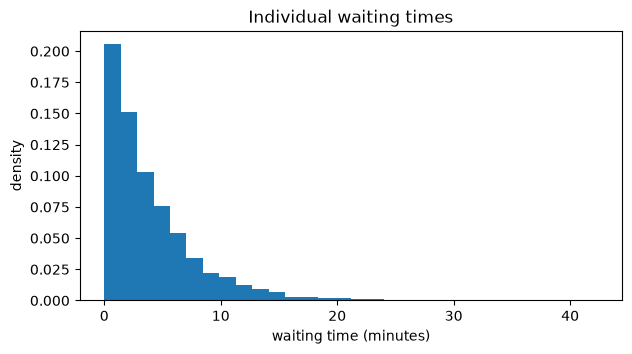

In [9]:
rng = np.random.default_rng(1451)
waiting_times = rng.exponential(scale=4.0, size=(5000, 40))

# First, look at the distribution of individual waiting times.
plt.figure(figsize=(7, 3.5))
plt.hist(waiting_times[:, 0], bins=30, density=True)
plt.xlabel("waiting time (minutes)")
plt.ylabel("density")
plt.title("Individual waiting times")
plt.show()

# The row averages are provided so you can focus on the CLT.
means_4 = waiting_times[:, :4].mean(axis=1)
means_40 = waiting_times.mean(axis=1)

# Your summary table, SD comparison, and plots here


### B. Interpret (0.5 pt)

Compare center, spread, and shape for the two distributions of averages. Explain what the simulation illustrates about the **central limit theorem**, and distinguish it from the **law of large numbers**.

**Answer:**


## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA3",
  "export_n": 1,
  "session_date": "2026-09-20",
  "messages": [
    {"i": 1, "who": "student", "text": "Good afternoon! Is a for loop permitted for question A?"},
    {"i": 2, "who": "tutor", "text": "For LE3-1A, yes — a for loop is exactly what's asked for. The prompt specifically wants you to use range, an if statement, and .append() to build changes_loop and abrupt_pairs_loop. It's part B (the vectorized solution) where you're asked to avoid a loop and use np.diff() with a Boolean mask instead. Want to talk through how to set up the range so it lines up correctly with comparing neighboring positions?"},
    {"i": 3, "who": "student", "text": "Can you help me trouble shoot this code?"},
    {"i": 4, "who": "tutor", "text": "Sure — paste the cell you're working on, along with whatever output or error message you're getting."},
    {"i": 5, "who": "student", "text": "thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\n# Your code here\nobservation_count = len(thickness_nm)\nfor i in range(observation_count-1):\n    changes_loop[i] = thickness_nm[i+1] - thickness_nm[i]\n\n    if(changes_loop[i] >= settings[\"abrupt_change_nm\"]): #flagging abrubt changes\n        abrupt_pairs_loop[i] = (i+1,i+2)\n\nIndexError: list assignment index out of range", "code": true},
    {"i": 6, "who": "tutor", "text": "Explained that changes_loop starts empty and can't be assigned by index; use .append() instead. Also flagged that the if condition checks signed change, not magnitude, and asked whether a negative change like -6 would be caught."},
    {"i": 7, "who": "student", "text": "thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\n# Your code here\nobservation_count = len(thickness_nm)\nfor i in range(observation_count-1):\n    changes_loop.append(thickness_nm[i+1] - thickness_nm[i])\n\n    if(abs(changes_loop[i]) >= settings[\"abrupt_change_nm\"]): #flagging abrubt changes\n        abrupt_pairs_loop.append((i+1,i+2))", "code": true},
    {"i": 8, "who": "tutor", "text": "Confirmed correct: .append() used properly, abs() catches magnitude, >= matches rule, 1-based pairs correct. Asked if student wants to check output or move to part B."},
    {"i": 9, "who": "student", "text": "Can you explain how np.diff() works?"},
    {"i": 10, "who": "tutor", "text": "Explained np.diff on a toy array, that result has one fewer element than input, vectorized subtraction, sign preserved, np.abs() for magnitude, and how a Boolean mask flags qualifying diffs."},
    {"i": 11, "who": "student", "text": "thickness_nm_array = np.array(thickness_nm)\n\nchanges_vectorized = np.diff(thickness_nm_array)\nabrupt_pairs_vectorized_mask = np.abs(changes_vectorized) >= 5\nabrupt_pairs_vectorized = np.linspace(1,observation_count)[abrupt_pairs_vectorized_mask]\n\nprint(changes_vectorized)\nprint(abrupt_pairs_vectorized)\n\nequality_condition = np.array_equal(changes_loop,changes_vectorized)\nprint(...)\n\nIndexError: boolean index did not match indexed array along axis 0; size of axis is 50 but size of corresponding boolean axis is 7", "code": true},
    {"i": 12, "who": "tutor", "text": "Explained np.linspace defaults to 50 points, not matching the 7 diffs; asked what tool gives indices where mask is True, and how to turn a 0-based index into a 1-based pair."},
    {"i": 13, "who": "student", "text": "Is there a way to get an array from 1 to observation count that I can then reference with the mask?"},
    {"i": 14, "who": "tutor", "text": "Explained np.arange(start, stop) as vectorized range, stop excluded, and asked what stop value includes observation_count, plus flagged the length mismatch between an 8-element positions array and 7-element mask."},
    {"i": 15, "who": "student", "text": "Is there a way I can have the arranged list as a touple with (i,i+1) to reference the next position in the continuous array starting at 1?"},
    {"i": 16, "who": "tutor", "text": "Explained np.where(mask) for 0-based True indices, and zip(a,b) for pairing sequences with an example, and asked student to connect the 0-based to 1-based shift."},
    {"i": 17, "who": "student", "text": "thickness_nm_array = np.array(thickness_nm)\n\nchanges_vectorized = np.diff(thickness_nm_array)\nabrupt_pairs_vectorized_mask = np.abs(changes_vectorized) >= 5\nobservations_arranged = np.arange(1,observation_count)\nobservations_arranged_list = list(zip(observations_arranged,observations_arranged+1))\nabrupt_pairs_vectorized = observations_arranged_list[abrupt_pairs_vectorized_mask]\n\nprint(changes_vectorized)\nprint(abrupt_pairs_vectorized)\n\nequality_condition = np.array_equal(changes_loop,changes_vectorized)\nprint(...)", "code": true},
    {"i": 18, "who": "tutor", "text": "Pointed out observations_arranged_list is a plain Python list and can't be Boolean-masked like a NumPy array, and that np.arange(1, observation_count) stops one short of the needed 8 positions."},
    {"i": 19, "who": "student", "text": "abrupt_pairs_vectorized = observations_arranged_list(abrupt_pairs_vectorized_mask)\n\nTypeError: 'list' object is not callable", "code": true},
    {"i": 20, "who": "tutor", "text": "Explained the parentheses-vs-brackets typo, and reiterated that a plain list still can't be Boolean-masked even with brackets — needs to stay a NumPy array before masking."},
    {"i": 21, "who": "student", "text": "thickness_nm_array = np.array(thickness_nm)\n\nchanges_vectorized = np.diff(thickness_nm_array)\nabrupt_pairs_vectorized_mask = np.abs(changes_vectorized) >= 5\nabrupt_pairs_vectorized = np.arange(1,observation_count)[abrupt_pairs_vectorized_mask]\nabrupt_pairs_vectorized = list(zip(abrupt_pairs_vectorized,abrupt_pairs_vectorized+1))\n\nprint(changes_vectorized)\nprint(abrupt_pairs_vectorized)\n\nequality_condition = np.array_equal(changes_loop,changes_vectorized)\nprint(...)\n\n[question: output includes numpy variable types, how to fix?]", "code": true},
    {"i": 22, "who": "tutor", "text": "Explained why iterating a NumPy array yields np.int64 scalars, suggested .astype(int) before zip or a comprehension casting with int()."},
    {"i": 23, "who": "student", "text": "The output remains unchanged"},
    {"i": 24, "who": "tutor", "text": "Asked student to paste the updated code to see what was tried."},
    {"i": 25, "who": "student", "text": "abrupt_pairs_vectorized = list(zip(abrupt_pairs_vectorized.astype(int),(abrupt_pairs_vectorized+1).astype(int)))\n\nOutput:\n[ 2 -1  6  1 -3  6 -1]\n[(np.int64(3), np.int64(4)), (np.int64(6), np.int64(7))]\nConsecutive measurement changes parity between loop and vectorization: True", "code": true},
    {"i": 26, "who": "tutor", "text": "Explained .astype(int) changes dtype but iterating still yields NumPy scalar objects, not native Python ints; per-element int() or .item() needed inside the comprehension, not .astype() on the array."},
    {"i": 27, "who": "student", "text": "Is there a way to re convert numpy arrays?"},
    {"i": 28, "who": "tutor", "text": "Explained .item() for a single NumPy scalar and .tolist() for converting a whole array to a plain Python list with native types."},
    {"i": 29, "who": "student", "text": "Is there a command simmilar to np.array_eqaul that I can use to identifiy python lists"},
    {"i": 30, "who": "tutor", "text": "Explained plain == works directly on Python lists/tuples for element-wise recursive comparison, unlike NumPy arrays which need np.array_equal."},
    {"i": 31, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 5, "part": "3-1A", "type": "code"},
    {"i": 7, "part": "3-1A", "type": "code"},
    {"i": 7, "part": "3-1A", "type": "part_pass"},
    {"i": 11, "part": "3-1B", "type": "code"},
    {"i": 17, "part": "3-1B", "type": "code"},
    {"i": 19, "part": "3-1B", "type": "code"},
    {"i": 21, "part": "3-1B", "type": "code"},
    {"i": 21, "part": "3-1B", "type": "part_pass"},
    {"i": 25, "part": "3-1B", "type": "code"}
  ],
  "parts": [
    {"part": "3-1A", "exchanges": 2, "max_tier": 1, "passed": true},
    {"part": "3-1B", "exchanges": 5, "max_tier": 3, "passed": true}
  ],
  "tutor_assessment": [
    "The student stalled longest on 3-1B — specifically converting the Boolean mask into 1-based position pairs. Confusions stacked: np.linspace's default 50 points, a plain list vs. NumPy array not supporting Boolean masking, a parentheses/brackets typo, and finally NumPy scalar types persisting through zip despite .astype(int). The underlying logic (mask -> positions -> pairs -> agreement check) was sound throughout; the friction was syntax and type mechanics, not the assignment's core reasoning.",
    "No release valve or self-declared 'unstuck' was used this session; the student worked through each snag with targeted questions and the ladder progressed naturally without needing to hand over finished code."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA3",
  "export_n": 2,
  "session_date": "2026-09-20",
  "messages": [
    {"i": 1, "who": "student", "text": "Good afternoon! Is a for loop permitted for question A?"},
    {"i": 2, "who": "tutor", "text": "For LE3-1A, yes — a for loop is exactly what's asked for. The prompt specifically wants you to use range, an if statement, and .append() to build changes_loop and abrupt_pairs_loop. It's part B (the vectorized solution) where you're asked to avoid a loop and use np.diff() with a Boolean mask instead. Want to talk through how to set up the range so it lines up correctly with comparing neighboring positions?"},
    {"i": 3, "who": "student", "text": "Can you help me trouble shoot this code?"},
    {"i": 4, "who": "tutor", "text": "Sure — paste the cell you're working on, along with whatever output or error message you're getting."},
    {"i": 5, "who": "student", "text": "thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\n# Your code here\nobservation_count = len(thickness_nm)\nfor i in range(observation_count-1):\n    changes_loop[i] = thickness_nm[i+1] - thickness_nm[i]\n\n    if(changes_loop[i] >= settings[\"abrupt_change_nm\"]): #flagging abrubt changes\n        abrupt_pairs_loop[i] = (i+1,i+2)\n\nIndexError: list assignment index out of range", "code": true},
    {"i": 6, "who": "tutor", "text": "Explained changes_loop starts empty and can't be assigned by index; use .append() instead. Also flagged that the if condition checks signed change, not magnitude."},
    {"i": 7, "who": "student", "text": "thickness_nm = [101, 103, 102, 108, 109, 106, 112, 111]\nsettings = {\"abrupt_change_nm\": 5}\n\nchanges_loop = []\nabrupt_pairs_loop = []\n\n# Your code here\nobservation_count = len(thickness_nm)\nfor i in range(observation_count-1):\n    changes_loop.append(thickness_nm[i+1] - thickness_nm[i])\n\n    if(abs(changes_loop[i]) >= settings[\"abrupt_change_nm\"]): #flagging abrubt changes\n        abrupt_pairs_loop.append((i+1,i+2))", "code": true},
    {"i": 8, "who": "tutor", "text": "Confirmed correct: .append() used properly, abs() catches magnitude, >= matches rule, 1-based pairs correct."},
    {"i": 9, "who": "student", "text": "Can you explain how np.diff() works?"},
    {"i": 10, "who": "tutor", "text": "Explained np.diff on a toy array, result has one fewer element, vectorized subtraction, sign preserved, np.abs() for magnitude, Boolean mask concept."},
    {"i": 11, "who": "student", "text": "thickness_nm_array = np.array(thickness_nm)\n\nchanges_vectorized = np.diff(thickness_nm_array)\nabrupt_pairs_vectorized_mask = np.abs(changes_vectorized) >= 5\nabrupt_pairs_vectorized = np.linspace(1,observation_count)[abrupt_pairs_vectorized_mask]\n\nprint(changes_vectorized)\nprint(abrupt_pairs_vectorized)\n\nequality_condition = np.array_equal(changes_loop,changes_vectorized)\nprint(...)\n\nIndexError: boolean index did not match indexed array along axis 0; size of axis is 50 but size of corresponding boolean axis is 7", "code": true},
    {"i": 12, "who": "tutor", "text": "Explained np.linspace defaults to 50 points; asked what tool gives indices where mask is True, and how to convert a 0-based index to a 1-based pair."},
    {"i": 13, "who": "student", "text": "Is there a way to get an array from 1 to observation count that I can then reference with the mask?"},
    {"i": 14, "who": "tutor", "text": "Explained np.arange(start, stop), stop excluded, asked what stop value includes observation_count, flagged length mismatch."},
    {"i": 15, "who": "student", "text": "Is there a way I can have the arranged list as a touple with (i,i+1) to reference the next position in the continuous array starting at 1?"},
    {"i": 16, "who": "tutor", "text": "Explained np.where(mask) and zip(a,b) with an example, asked student to connect 0-based to 1-based shift."},
    {"i": 17, "who": "student", "text": "thickness_nm_array = np.array(thickness_nm)\n\nchanges_vectorized = np.diff(thickness_nm_array)\nabrupt_pairs_vectorized_mask = np.abs(changes_vectorized) >= 5\nobservations_arranged = np.arange(1,observation_count)\nobservations_arranged_list = list(zip(observations_arranged,observations_arranged+1))\nabrupt_pairs_vectorized = observations_arranged_list[abrupt_pairs_vectorized_mask]\n\nprint(changes_vectorized)\nprint(abrupt_pairs_vectorized)\n\nequality_condition = np.array_equal(changes_loop,changes_vectorized)\nprint(...)", "code": true},
    {"i": 18, "who": "tutor", "text": "Pointed out observations_arranged_list is a plain Python list and can't be Boolean-masked, and that np.arange(1, observation_count) stops one short."},
    {"i": 19, "who": "student", "text": "abrupt_pairs_vectorized = observations_arranged_list(abrupt_pairs_vectorized_mask)\n\nTypeError: 'list' object is not callable", "code": true},
    {"i": 20, "who": "tutor", "text": "Explained parentheses-vs-brackets typo, reiterated plain list still can't be Boolean-masked."},
    {"i": 21, "who": "student", "text": "thickness_nm_array = np.array(thickness_nm)\n\nchanges_vectorized = np.diff(thickness_nm_array)\nabrupt_pairs_vectorized_mask = np.abs(changes_vectorized) >= 5\nabrupt_pairs_vectorized = np.arange(1,observation_count)[abrupt_pairs_vectorized_mask]\nabrupt_pairs_vectorized = list(zip(abrupt_pairs_vectorized,abrupt_pairs_vectorized+1))\n\nprint(changes_vectorized)\nprint(abrupt_pairs_vectorized)\n\nequality_condition = np.array_equal(changes_loop,changes_vectorized)\nprint(...)\n\n[question: output includes numpy variable types, how to fix?]", "code": true},
    {"i": 22, "who": "tutor", "text": "Explained why iterating a NumPy array yields np.int64 scalars, suggested .astype(int) before zip or a comprehension casting with int()."},
    {"i": 23, "who": "student", "text": "The output remains unchanged"},
    {"i": 24, "who": "tutor", "text": "Asked student to paste the updated code to see what was tried."},
    {"i": 25, "who": "student", "text": "abrupt_pairs_vectorized = list(zip(abrupt_pairs_vectorized.astype(int),(abrupt_pairs_vectorized+1).astype(int)))\n\nOutput:\n[ 2 -1  6  1 -3  6 -1]\n[(np.int64(3), np.int64(4)), (np.int64(6), np.int64(7))]\nConsecutive measurement changes parity between loop and vectorization: True", "code": true},
    {"i": 26, "who": "tutor", "text": "Explained .astype(int) changes dtype but iterating still yields NumPy scalar objects; per-element int() or .item() needed inside a comprehension."},
    {"i": 27, "who": "student", "text": "Is there a way to re convert numpy arrays?"},
    {"i": 28, "who": "tutor", "text": "Explained .item() for a single NumPy scalar and .tolist() for converting a whole array to native Python types."},
    {"i": 29, "who": "student", "text": "Is there a command simmilar to np.array_eqaul that I can use to identifiy python lists"},
    {"i": 30, "who": "tutor", "text": "Explained plain == works directly on Python lists/tuples for element-wise recursive comparison."},
    {"i": 31, "who": "student", "text": "make my record"},
    {"i": 32, "who": "tutor", "text": "[produced export_n 1]"},
    {"i": 33, "who": "student", "text": "How can I use np.histogram?"},
    {"i": 34, "who": "tutor", "text": "Explained np.histogram(data, bins=...) returns counts and edges, unpacking order, density=True meaning, bins as number or array."},
    {"i": 35, "who": "student", "text": "What does \\sum_i (\\text{density}_i)(\\text{bin width}_i)=1. mean?"},
    {"i": 36, "who": "tutor", "text": "Broke down summation notation: sigma, subscript i, density_i, bin width_i, product as bar area, total area equals 1, connected to density=True."},
    {"i": 37, "who": "student", "text": "Can you generate an image of the text output? My jupyter notebook wont display it"},
    {"i": 38, "who": "tutor", "text": "Asked for clarification on what's not displaying — plot vs print output vs something else — declined to generate an image as a workaround."},
    {"i": 39, "who": "student", "text": "I need the text output of this notation: \\sum_i (\\text{density}_i)(\\text{bin width}_i)=1."},
    {"i": 40, "who": "tutor", "text": "Provided plain Unicode rendering: Σᵢ (densityᵢ)(bin widthᵢ) = 1, with spelled-out meaning."},
    {"i": 41, "who": "student", "text": "Is there a way I can get the bin number from np.histogram()"},
    {"i": 42, "who": "tutor", "text": "Explained len(heights) or len(edges)-1 gives bin count, with toy example."},
    {"i": 43, "who": "student", "text": "Can you explain the difference between norm.pdf and norm.cdf?"},
    {"i": 44, "who": "tutor", "text": "Explained pdf as height/density at a point (not a probability), cdf as left-tail cumulative probability, with toy examples."},
    {"i": 45, "who": "student", "text": "Can you explain and show examples of all of the function relatives?"},
    {"i": 46, "who": "tutor", "text": "Explained cdf, sf, ppf, isf with toy examples and pairing (cdf-ppf, sf-isf), asked which fits LE3-3B."},
    {"i": 47, "who": "student",

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
